# Подготовка и первичный анализ данных билетных продаж сервиса «Яндекс Афиша»

**Автор:** Екатерина Штрейс  
**Дата:** 1 июня 2026 года

## О проекте

Исследование посвящено данным о бронировании билетов в сервисе «Яндекс Афиша» за период с июня по октябрь 2024 года. Анализ охватывает структуру заказов, пользовательские устройства, категории событий, географию продаж и распределение выручки.

На текущем этапе выполнены объединение источников, контроль качества данных, анализ категориальных признаков, оценка распределений и подготовка аналитической выборки. Отдельное внимание уделено заказам в разных валютах, потенциальным дубликатам и аномально крупным значениям выручки.

## Данные

В проекте используются три набора данных:

- `final_tickets_orders_df.csv` — заказы билетов, оформленные с мобильных и стационарных устройств;
- `final_tickets_events_df.csv` — сведения о событиях, организаторах, городах и площадках;
- `final_tickets_tenge_df.csv` — курс тенге к российскому рублю за 2024 год.

Основные признаки заказов включают идентификаторы пользователя, заказа и события, дату покупки, тип устройства, валюту, выручку, количество билетов и интервал с предыдущей покупки. Таблица событий содержит категорию мероприятия, организатора, регион, город и площадку проведения.

## 1. Загрузка и первичный обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
DATA_URL = 'https://code.s3.yandex.net/datasets/'

final_tickets_orders_df = pd.read_csv(DATA_URL + 'final_tickets_orders_df.csv')
display(final_tickets_orders_df.head())
final_tickets_orders_df.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [3]:
final_tickets_events_df = pd.read_csv(DATA_URL + 'final_tickets_events_df.csv')
display(final_tickets_events_df.head())
final_tickets_events_df.info()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [4]:
final_tickets_tenge_df = pd.read_csv(DATA_URL + 'final_tickets_tenge_df.csv')
display(final_tickets_tenge_df.head())
final_tickets_tenge_df.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


### Результаты первичного обзора

Наборы данных загружены корректно и соответствуют заявленной структуре. Пропуски в таблице заказов сосредоточены в поле `days_since_prev`: они соответствуют пользователям, для которых текущая покупка является первой.

Поля с датами требуют преобразования в формат `datetime`. Идентификатор пользователя сохраняется как строковый признак, а ограниченный набор категориальных полей может быть переведён в тип `category` для оптимизации памяти.

## 2. Объединение и предобработка данных

In [5]:
print('orders до объединения:', final_tickets_orders_df.shape[0])

df_check = final_tickets_orders_df.merge(
    final_tickets_events_df,
    on='event_id',
    how='left',
    indicator=True
)

print(df_check['_merge'].value_counts())

orders до объединения: 290849
both          290611
left_only        238
right_only         0
Name: _merge, dtype: int64


In [6]:
df = final_tickets_orders_df.merge(
    final_tickets_events_df,
    on='event_id',
    how='inner'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

Таблицы заказов и событий объединены по идентификатору `event_id`. Перед дальнейшим анализом проверяется доля заказов без соответствующего события и структура полученного набора данных.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

In [9]:
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')
print(f'Количество полных дубликатов строк: {df.duplicated().sum()}')
print(f'Количество пропусков в данных: {df.isna().sum().sum()}')

Количество строк: 290611
Количество столбцов: 24
Количество полных дубликатов строк: 0
Количество пропусков в данных: 21913


In [27]:
lost_rows = (df_check['_merge'] != 'both').sum()
lost_share = lost_rows / len(final_tickets_orders_df) * 100

print(f'Заказов без соответствия в справочнике событий: {lost_rows}')
print(f'Доля таких заказов: {lost_share:.4f}%')

Потерянно заказов: 238
Процент потерянных заказов: 0.0818%


Небольшая часть заказов не получила соответствия в таблице событий. Их доля незначительна; вероятная причина — предварительная фильтрация отдельных типов мероприятий при подготовке справочника событий.

Пропуски обнаружены только в `days_since_prev` и интерпретируются как отсутствие предыдущей покупки. Полные дубликаты отсутствуют.

`user_id` сохраняется в строковом формате как идентификатор. Поля `created_dt_msk` и `created_ts_msk` преобразуются в `datetime`. Возрастное ограничение рассматривается как категориальный признак, а поля `cinema_circuit`, `currency_code` и `device_type_canonical` переводятся в тип `category`.

### 2.1. Контроль категориальных признаков

In [39]:
categorical_columns = [
    'age_limit',
    'cinema_circuit',
    'currency_code',
    'device_type_canonical',
    'service_name',
    'event_type_main',
    'event_type_description',
    'region_name',
    'city_name',
    'venue_name'
]

for col in categorical_columns:
    print('\n', col)
    print( df[col].nunique())
    print(df[col].value_counts().head(10))


 age_limit
5
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64

 cinema_circuit
6
нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

 currency_code
2
rub    285542
kzt      5069
Name: currency_code, dtype: int64

 device_type_canonical
2
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

 service_name
36
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: service_name, dtype: int64

 event_type_main
7
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

 event_type

### Результаты анализа категориальных признаков

Категориальные значения представлены согласованно, явных технических заглушек или ошибочных категорий не обнаружено.

В данных присутствуют пять возрастных ограничений и два типа устройств. Мобильный канал доминирует по количеству заказов. Большинство операций проведено в рублях, однако часть заказов оплачена в тенге, поэтому финансовые показатели необходимо приводить к единой валюте.

Наиболее крупной категорией событий являются концерты. Данные охватывают 81 регион, 352 города и более трёх тысяч площадок, поэтому географический анализ целесообразно проводить по лидирующим регионам и площадкам, дополняя абсолютные значения относительными долями.

In [42]:
category_columns = [
    'age_limit',
    'cinema_circuit',
    'currency_code',
    'device_type_canonical'
]

for column in category_columns:
    df[column] = df[column].astype('category')

print(df[category_columns].dtypes)

age_limit                category
cinema_circuit           category
currency_code            category
device_type_canonical    category
dtype: object


### 2.2. Распределения числовых признаков и выбросы

Распределения выручки и количества билетов оцениваются отдельно по валютам. Для снижения влияния единичных экстремальных заказов верхняя граница выручки определяется на уровне 99-го процентиля. Отрицательные значения сохраняются, поскольку могут отражать возвраты и влияют на итоговую экономику продаж.

In [12]:
# Общая статистика в рублях
df_rub = df[df['currency_code'] == 'rub']

df_rub[['revenue', 'tickets_count', 'total', 'days_since_prev']].describe()

,revenue,tickets_count,total,days_since_prev
count,285542.000000,285542.000000,285542.000000,264497.000000
mean,548.013929,2.754159,6330.621221,3.209919
std,871.750181,1.171575,8619.327495,11.316096
min,-90.760000,1.000000,-358.850000,0.000000
25%,114.170000,2.000000,2120.070000,0.000000
50%,346.630000,3.000000,4673.850000,0.000000
75%,793.320000,4.000000,8783.220000,1.000000
max,81174.540000,57.000000,811745.400000,148.000000


In [19]:
# В процентах пропуски days_since_prev
print(f"{round(df['days_since_prev'].isna().mean() * 100, 1)}%")

7.5%


### Особенности числовых данных

В `revenue` и `total` присутствуют отрицательные значения, которые могут соответствовать возвратам. Распределение выручки имеет выраженный правый хвост и содержит единичные крупные заказы. Количество билетов также включает редкие высокие значения, однако они могут отражать групповые покупки и не удаляются автоматически.

Для дальнейшего анализа формируется выборка, ограниченная 99-м процентилем выручки отдельно для рублей и тенге. Пропуски в `days_since_prev` составляют около 7,5% и соответствуют первым покупкам пользователей.

Высокое стандартное отклонение выручки подтверждает неоднородность заказов и чувствительность среднего значения к крупным покупкам. Нулевые значения требуют отдельной бизнес-интерпретации: они могут быть связаны с промоакциями, бесплатными билетами или особенностями учёта операций.

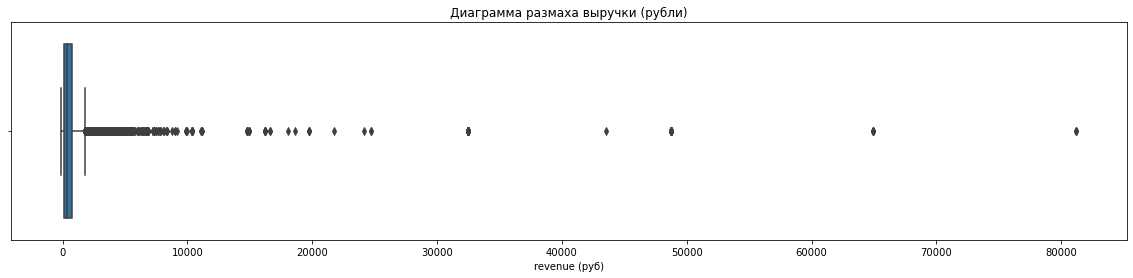

In [13]:
df_rub = df[df['currency_code'] == 'rub']

plt.figure(figsize=(20, 4))
sns.boxplot(x=df_rub['revenue'])
plt.title('Диаграмма размаха выручки (рубли)')
plt.xlabel('revenue (руб)')
plt.show()

Основная масса рублёвых заказов сосредоточена в нижней части распределения; после приблизительно 26 тыс. рублей наблюдения становятся единичными. Для аналитической выборки применяется ограничение по 99-му процентилю.

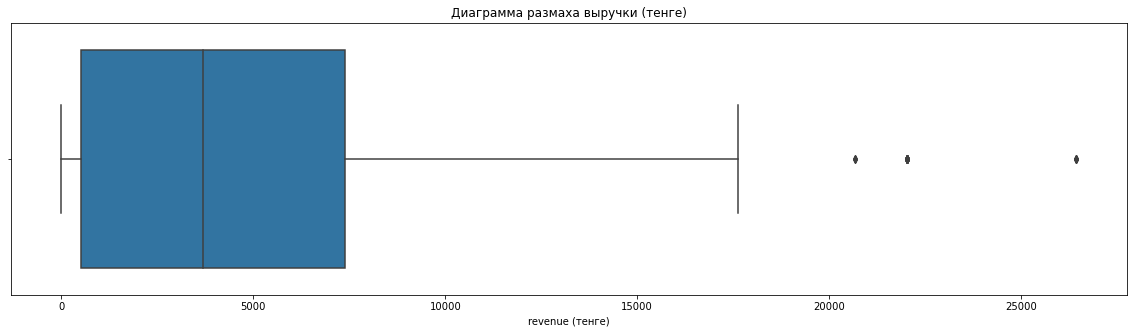

In [14]:
# Ящик с усами для тенге
df_kzt = df[df['currency_code'] == 'kzt']

plt.figure(figsize=(20, 5))
sns.boxplot(x=df_kzt['revenue'])
plt.title('Диаграмма размаха выручки (тенге)')
plt.xlabel('revenue (тенге)')
plt.show()

Распределение выручки в тенге также имеет выраженный правый хвост. Большинство заказов находится в нижнем ценовом диапазоне, а крупные значения встречаются редко и обрабатываются отдельным порогом для этой валюты.

In [44]:
q99_rub = df.loc[df['currency_code'] == 'rub', 'revenue'].quantile(0.99)
q99_kzt = df.loc[df['currency_code'] == 'kzt', 'revenue'].quantile(0.99)

print('99-й процентиль RUB:', q99_rub)
print('99-й процентиль KZT:', q99_kzt)

df_filtered = df[
    ((df['currency_code'] == 'rub') & (df['revenue'] <= q99_rub)) |
    ((df['currency_code'] == 'kzt') & (df['revenue'] <= q99_kzt))
].copy()

print('До фильтрации:', df.shape[0])
print('После фильтрации:', df_filtered.shape[0])
print('Удалено строк:', df.shape[0] - df_filtered.shape[0])

99-й процентиль RUB: 2570.8
99-й процентиль KZT: 17617.24
До фильтрации: 290611
После фильтрации: 287782
Удалено строк: 2829


In [50]:
# Неявные дубликаты
duplicate_cols = [
    'user_id',
    'created_dt_msk',
    'created_ts_msk',
    'event_id',
    'currency_code',
    'device_type_canonical',
    'revenue',
    'tickets_count',
    'total'
]

implicit_duplicates = df[df.duplicated(subset=duplicate_cols, keep=False)]

print('Количество возможных неявных дубликатов:', implicit_duplicates.shape[0])
display(implicit_duplicates.sort_values(duplicate_cols).head(10))

Количество возможных неявных дубликатов: 77


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
184947,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
184948,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
126876,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
126878,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
43477,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213,4363,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
43479,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213,4363,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
255954,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036,1656,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
255957,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036,1656,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
261913,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43,3873,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"
261914,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43,3873,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"


In [53]:
duplicates_count = implicit_duplicates.shape[0]
total_rows = df.shape[0]
duplicates_share = duplicates_count / total_rows * 100

print(f'Количество возможных неявных дубликатов: {duplicates_count}')
print(f'Доля возможных неявных дубликатов: {duplicates_share:.4f}%')

Количество возможных неявных дубликатов: 77
Доля возможных неявных дубликатов: 0.0265%


Обнаружено 77 строк, совпадающих по набору ключевых признаков без учёта идентификатора заказа. Их доля составляет около 0,03% от объёма данных. Поскольку совпадения могут соответствовать реальным повторным заказам, записи сохраняются в выборке.

In [56]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

if 'df_filtered' in globals():
    df_filtered['created_dt_msk'] = pd.to_datetime(df_filtered['created_dt_msk'])
    df_filtered['created_ts_msk'] = pd.to_datetime(df_filtered['created_ts_msk'])

df[['created_dt_msk', 'created_ts_msk']].dtypes

AttributeError: 'Series' object has no attribute 'info'

## Итог подготовки данных

Данные объединены и приведены к форматам, подходящим для дальнейшего анализа. Категориальные признаки проверены, временные поля преобразованы, потенциальные дубликаты оценены, а для выручки сформированы валютно-зависимые пороги выбросов.

Следующий этап исследования может включать анализ динамики продаж, сравнение мобильного и десктопного каналов, оценку популярных категорий событий, организаторов и площадок, а также пересчёт финансовых показателей в единую валюту.